# 05 -- Retrieval-Augmented Generation (RAG) for Security

This notebook builds on `03_security_foundation_model.ipynb` and `04_security_model_evaluation.ipynb`. Same `.venv`, same `Foundation-Sec-1.1-8B-Instruct` Q4_K_M model (not re-downloaded), notebooks 00-04 untouched.

**Goal:** demonstrate Retrieval-Augmented Generation (RAG) and directly compare model-only answers against retrieval-grounded answers on questions that require organization-specific knowledge the model was never trained on.

## Section 1 -- The problem RAG solves

A foundation model contains only the knowledge it saw during training. It does not automatically know anything organization-specific or anything that changed after its training data was collected. For a security product, that gap includes things like:

- internal security policies
- approved incident response procedures
- asset criticality classifications
- current threat intelligence
- current vulnerabilities
- customer-specific configuration

**Why not just put all of this into training?** Training (or fine-tuning) is slow, expensive, and produces a static snapshot -- the moment a policy changes, the model is out of date again until it's retrained. It also doesn't scale to per-customer information: a security product serving many organizations cannot bake each customer's private policies into one shared model's weights, both for cost reasons and because it would leak one customer's information into a model that serves others.

**RAG's answer:** retrieve the relevant information at inference time and hand it to the model as context, rather than trying to make the model memorize it. The model's weights never change. What changes is what the model is shown right before it answers.

## Section 2 -- A small security knowledge base

Five short **synthetic** Markdown policy documents live in [`data/security_knowledge/`](../data/security_knowledge/) -- real files on disk, not generated inline, so they can be inspected and version-controlled like any other project source. Every document is explicitly marked synthetic at the top; none of this is a real organization's policy, and no customer or sensitive data is used anywhere in this notebook.

- `incident_response_policy.md` -- escalation rules, account-disable approval rules, endpoint isolation approval rules
- `authentication_policy.md` -- MFA requirements, impossible travel handling, privileged/service account rules
- `endpoint_response_policy.md` -- when isolation is allowed, evidence required before containment
- `threat_intelligence_policy.md` -- how to handle suspicious IPs by reputation confidence, indicator freshness
- `asset_criticality.md` -- criticality tiers and required containment response times

These documents deliberately contain specific, invented numbers (15 minutes, 60 days, a 40-79 confidence band, and so on) that Foundation-Sec cannot possibly know from training -- which is exactly what makes the baseline-vs-RAG comparison in Section 6 meaningful rather than cosmetic.

In [1]:
from pathlib import Path

KB_DIR = Path("..") / "data" / "security_knowledge"
kb_files = sorted(KB_DIR.glob("*.md"))

print(f"Knowledge base: {len(kb_files)} documents")
for f in kb_files:
    print(f" - {f.name} ({f.stat().st_size} bytes)")

Knowledge base: 5 documents
 - asset_criticality.md (894 bytes)
 - authentication_policy.md (1174 bytes)
 - endpoint_response_policy.md (993 bytes)
 - incident_response_policy.md (1212 bytes)
 - threat_intelligence_policy.md (985 bytes)


## Section 3 -- Simple retrieval first

This notebook deliberately does **not** start with a vector database or embeddings. It implements **TF-IDF cosine-similarity retrieval by hand** -- about 25 lines of plain Python, fully inspectable, no new dependency. TF-IDF (term frequency times inverse document frequency) scores a word higher in a chunk the more often it appears there, but lower overall the more chunks across the whole knowledge base it appears in -- so common words like "the" or "policy" get downweighted automatically, while distinctive words like "impossible travel" or "vssadmin" carry more weight.

**This is retrieval, not training.** Nothing here touches the model's weights -- `llm` stays exactly the same loaded object as notebook 03/04. Retrieval only decides which pre-existing text gets pasted into the prompt before the model ever sees the question.

## Section 4 -- Chunking

Documents are split on their `## ` section headers -- each chunk stores which `document` it came from, which `section` heading it belongs to, and its `text`. Chunking is necessary because a retrieval query should return the *specific* relevant passage, not an entire multi-topic document that would waste context and dilute relevance.

**The size tradeoff:**
- **Too large** (e.g. whole documents) -- pulls in irrelevant sections alongside the relevant one, inflates the prompt, costs more, and can bury the actually-relevant sentence in noise.
- **Too small** (e.g. single sentences) -- loses surrounding context a sentence needs to be understood correctly, and fragments a coherent policy rule across multiple disconnected chunks, hurting retrieval quality.

Section-level chunking is a reasonable middle ground for short policy documents like these -- each chunk is one coherent rule area, small enough to be specific, large enough to stay meaningful on its own.

In [2]:
import re


def load_and_chunk(md_path):
    text = md_path.read_text()
    parts = re.split(r"(?m)^## ", text)
    chunks = []
    preamble = parts[0].strip()
    if preamble:
        chunks.append({"document": md_path.name, "section": "Overview", "text": preamble})
    for part in parts[1:]:
        lines = part.split("\n", 1)
        section_title = lines[0].strip()
        body = lines[1].strip() if len(lines) > 1 else ""
        chunks.append({"document": md_path.name, "section": section_title, "text": f"## {section_title}\n{body}"})
    return chunks


all_chunks = []
for f in kb_files:
    all_chunks.extend(load_and_chunk(f))

print(f"{len(all_chunks)} chunks created from {len(kb_files)} documents\n")
for c in all_chunks:
    print(f"[{c['document']:<32}] {c['section']:<28} ({len(c['text'])} chars)")

21 chunks created from 5 documents

[asset_criticality.md            ] Overview                     (181 chars)
[asset_criticality.md            ] Criticality Tiers            (324 chars)
[asset_criticality.md            ] Response Time Expectations   (382 chars)
[authentication_policy.md        ] Overview                     (170 chars)
[authentication_policy.md        ] Multi-Factor Authentication (MFA) (292 chars)
[authentication_policy.md        ] Impossible Travel            (283 chars)
[authentication_policy.md        ] Privileged Accounts          (244 chars)
[authentication_policy.md        ] Service Accounts             (172 chars)
[endpoint_response_policy.md     ] Overview                     (173 chars)
[endpoint_response_policy.md     ] When Isolation Is Allowed    (215 chars)
[endpoint_response_policy.md     ] Evidence Required Before Containment (407 chars)
[endpoint_response_policy.md     ] Approval Chain               (188 chars)
[incident_response_policy.md     ] Over

## Section 5 -- Retrieval and the RAG prompt

Given a question: build a TF-IDF vector for it, score it against every chunk's TF-IDF vector by cosine similarity, and take the top-3 chunks. Those chunks are placed under a **`SECURITY CONTEXT`** heading, clearly separated from the **`USER QUESTION`**, with an explicit instruction not to invent policy and to say so if the context doesn't support an answer -- exactly the instruction the task requires.

In [3]:
import math
from collections import Counter


def tokenize(text):
    return re.findall(r"[a-z0-9]+", text.lower())


def build_tfidf_index(chunks):
    doc_tokens = [tokenize(c["text"]) for c in chunks]
    df = Counter()
    for tokens in doc_tokens:
        for term in set(tokens):
            df[term] += 1
    n_docs = len(chunks)
    idf = {term: math.log((n_docs + 1) / (freq + 1)) + 1 for term, freq in df.items()}
    vectors = []
    for tokens in doc_tokens:
        tf = Counter(tokens)
        length = len(tokens) or 1
        vectors.append({term: (count / length) * idf.get(term, 0.0) for term, count in tf.items()})
    return vectors, idf


def vectorize_query(query, idf):
    tokens = tokenize(query)
    tf = Counter(tokens)
    length = len(tokens) or 1
    return {term: (count / length) * idf.get(term, 0.0) for term, count in tf.items()}


def cosine_similarity(vec_a, vec_b):
    common = set(vec_a) & set(vec_b)
    dot = sum(vec_a[t] * vec_b[t] for t in common)
    norm_a = math.sqrt(sum(v * v for v in vec_a.values()))
    norm_b = math.sqrt(sum(v * v for v in vec_b.values()))
    return 0.0 if norm_a == 0 or norm_b == 0 else dot / (norm_a * norm_b)


def retrieve(query, chunks, tfidf_vectors, idf, top_k=3):
    query_vec = vectorize_query(query, idf)
    scores = [(i, cosine_similarity(query_vec, vec)) for i, vec in enumerate(tfidf_vectors)]
    scores.sort(key=lambda x: x[1], reverse=True)
    return [(chunks[i], score) for i, score in scores[:top_k]]


tfidf_vectors, idf = build_tfidf_index(all_chunks)
TOP_K = 3

RAG_SYSTEM_PROMPT = (
    "You are a SOC analyst assistant. Use the supplied security context to answer the question. "
    "Do not invent policy. If the answer is not supported by the context, say so explicitly."
)


def build_rag_user_content(question, retrieved):
    context_text = "\n\n".join(f"[{c['document']} -- {c['section']}]\n{c['text']}" for c, _ in retrieved)
    return f"SECURITY CONTEXT:\n{context_text}\n\nUSER QUESTION:\n{question}"


# Quick demo of retrieval alone, before involving the model
demo_retrieved = retrieve("How often must privileged account passwords be rotated?", all_chunks, tfidf_vectors, idf, TOP_K)
for c, score in demo_retrieved:
    print(f"{score:.3f}  [{c['document']} -- {c['section']}]")

0.414  [authentication_policy.md -- Privileged Accounts]
0.257  [incident_response_policy.md -- Account Actions]
0.244  [authentication_policy.md -- Impossible Travel]


## Section 6 -- Baseline vs. RAG on 10 questions

10 questions, each targeting a specific fact that only exists in this synthetic knowledge base -- the model cannot know these answers from training. Question 10 is deliberately a gap the knowledge base does not cover (conflicting threat intel sources), to test whether the model appropriately says "the policy doesn't address this" rather than inventing an answer.

For every question we run **A. Foundation-Sec with no retrieval** (general knowledge only) and **B. Foundation-Sec with retrieval** (the RAG prompt from Section 5), and store both answers untouched.

In [4]:
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")

import time
from huggingface_hub import hf_hub_download
from llama_cpp import Llama

REPO_ID = "fdtn-ai/Foundation-Sec-1.1-8B-Instruct-Q4_K_M-GGUF"
FILENAME = "foundation-sec-1.1-8b-instruct-q4_k_m.gguf"

model_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME)  # resolves instantly -- already cached
print(f"Using cached model file: {FILENAME} (not re-downloaded)")

llm = Llama(model_path=model_path, n_ctx=2048, n_gpu_layers=-1, verbose=False)
print("Model loaded.")

BASELINE_SYSTEM_PROMPT = "You are a SOC analyst assistant. Answer the security question as best you can based on your own general knowledge."


def ask_baseline(question, max_tokens=200):
    messages = [{"role": "system", "content": BASELINE_SYSTEM_PROMPT}, {"role": "user", "content": question}]
    t0 = time.time()
    resp = llm.create_chat_completion(messages=messages, max_tokens=max_tokens, temperature=0.1)
    return resp["choices"][0]["message"]["content"].strip(), time.time() - t0


def ask_rag(question, retrieved, max_tokens=250):
    messages = [
        {"role": "system", "content": RAG_SYSTEM_PROMPT},
        {"role": "user", "content": build_rag_user_content(question, retrieved)},
    ]
    t0 = time.time()
    resp = llm.create_chat_completion(messages=messages, max_tokens=max_tokens, temperature=0.1)
    return resp["choices"][0]["message"]["content"].strip(), time.time() - t0


QUESTIONS = [
    {"id": "Q1", "question": "Can a Tier 1 analyst disable a privileged Domain Admin account without approval?",
     "target_documents": ["incident_response_policy.md"],
     "expected_facts": ["written approval", "tier 3", "soc manager"]},
    {"id": "Q2", "question": "Is MFA required for service account logins?",
     "target_documents": ["authentication_policy.md"],
     "expected_facts": ["exempt", "certificate"]},
    {"id": "Q3", "question": "What evidence is required before an analyst can isolate a non-ransomware endpoint?",
     "target_documents": ["endpoint_response_policy.md"],
     "expected_facts": ["at least two", "malicious process", "outbound connection", "file hash"]},
    {"id": "Q4", "question": "Can a suspicious IP address with a threat intelligence reputation score of 55 be blocked automatically?",
     "target_documents": ["threat_intelligence_policy.md"],
     "expected_facts": ["medium", "40-79", "verification"]},
    {"id": "Q5", "question": "How quickly must a compromised domain controller be contained?",
     "target_documents": ["asset_criticality.md"],
     "expected_facts": ["15 minutes", "critical"]},
    {"id": "Q6", "question": "How often must privileged account passwords be rotated?",
     "target_documents": ["authentication_policy.md"],
     "expected_facts": ["60 days"]},
    {"id": "Q7", "question": "During an active ransomware outbreak, does a Tier 1 analyst need approval before isolating an endpoint?",
     "target_documents": ["endpoint_response_policy.md", "incident_response_policy.md"],
     "expected_facts": ["without", "ransomware", "report after"]},
    {"id": "Q8", "question": "How old can a threat intelligence indicator be before it is considered stale?",
     "target_documents": ["threat_intelligence_policy.md"],
     "expected_facts": ["90 days"]},
    {"id": "Q9", "question": "What is the required containment start time for a compromised production server?",
     "target_documents": ["asset_criticality.md"],
     "expected_facts": ["1 hour", "high"]},
    {"id": "Q10", "question": "If two independent threat intelligence sources disagree about an IP address's reputation, what should the analyst do?",
     "target_documents": ["threat_intelligence_policy.md"],
     "expected_facts": [], "expects_gap_acknowledgment": True},
]

eval_results = []
for q in QUESTIONS:
    retrieved = retrieve(q["question"], all_chunks, tfidf_vectors, idf, TOP_K)
    baseline_answer, baseline_latency = ask_baseline(q["question"])
    rag_answer, rag_latency = ask_rag(q["question"], retrieved)
    eval_results.append({
        "id": q["id"], "question": q, "retrieved": retrieved,
        "baseline_answer": baseline_answer, "rag_answer": rag_answer,
        "baseline_latency": baseline_latency, "rag_latency": rag_latency,
    })
    print(f"{q['id']}: baseline {baseline_latency:.1f}s, RAG {rag_latency:.1f}s")

Using cached model file: foundation-sec-1.1-8b-instruct-q4_k_m.gguf (not re-downloaded)


Model loaded.


Q1: baseline 12.9s, RAG 4.4s


Q2: baseline 13.2s, RAG 2.8s


Q3: baseline 14.0s, RAG 1.0s


...

Q6: baseline 16.0s, RAG 2.0s


Q7: baseline 18.0s, RAG 5.3s


Q8: baseline 10.3s, RAG 1.1s


Q9: baseline 17.9s, RAG 13.9s


Q10: baseline 17.5s, RAG 1.6s


All 10 raw answers, printed in full and unedited, so every verdict in Section 7 can be checked against the actual text rather than taken on faith. Answers are shown with `repr()` (visible quote marks) specifically so an empty or whitespace-only response is visually obvious rather than silently blank.

In [5]:
for r in eval_results:
    print("=" * 90)
    print(f"{r['id']}: {r['question']['question']}")
    print(f"\n  BASELINE ({r['baseline_latency']:.1f}s):\n  {r['baseline_answer']!r}")
    print(f"\n  RAG ({r['rag_latency']:.1f}s):\n  {r['rag_answer']!r}")
    print()

Q1: Can a Tier 1 analyst disable a privileged Domain Admin account without approval?

  BASELINE (12.9s):
  "A Tier 1 analyst, typically the first line of defense in a Security Operations Center (SOC), generally does not have the authority to disable a privileged account such as a Domain Admin account without explicit approval. Privileged accounts, especially those with domain administrative rights, are highly sensitive and are used to manage and control the entire domain infrastructure. Disabling such an account can have significant impacts on the organization's IT operations and security posture.\n\nHere are the reasons why a Tier 1 analyst would not have the authority to disable a privileged account:\n\n1. **Privileged Access Control**: Access to privileged accounts is tightly controlled and usually requires multiple layers of approval and authentication. This is to prevent unauthorized changes that could lead to system instability or security breaches.\n\n2. **Impact on Operations*

## Section 7 -- Evaluate grounding

Each answer (baseline and RAG) is scored **correct**, **partially correct**, or **unsupported** by checking how many of that question's expected key facts (specific numbers, thresholds, or terms from the actual policy) appear in the answer text. For Q10 -- the deliberate gap case -- "correct" instead means the answer explicitly acknowledges the policy doesn't address the scenario, rather than inventing a rule that doesn't exist.

This heuristic is the same kind of transparent, approximate keyword check used in notebook 04 -- it catches the specific hallucination/policy-violation/missing-requirement failure modes this task cares about (a wrong number, a missing required approval step, an invented rule), but it is not a semantic judge. Read the actual text in Section 8 for the real evidence, not just the verdict label.

In [6]:
GAP_PHRASES = [
    "not specif", "does not specify", "does not address", "not covered", "not mentioned",
    "no explicit", "unclear from", "cannot determine", "not stated", "does not provide", "not clear",
]


def score_answer(answer_text, expected_facts, expects_gap_acknowledgment=False):
    text_lower = (answer_text or "").lower()
    if expects_gap_acknowledgment:
        acknowledged = any(phrase in text_lower for phrase in GAP_PHRASES)
        return "correct" if acknowledged else "unsupported"
    if not expected_facts:
        return "unsupported"
    hits = sum(1 for fact in expected_facts if fact.lower() in text_lower)
    fraction = hits / len(expected_facts)
    if fraction >= 0.7:
        return "correct"
    if fraction >= 0.3:
        return "partially correct"
    return "unsupported"


for r in eval_results:
    q = r["question"]
    r["baseline_verdict"] = score_answer(r["baseline_answer"], q["expected_facts"], q.get("expects_gap_acknowledgment", False))
    r["rag_verdict"] = score_answer(r["rag_answer"], q["expected_facts"], q.get("expects_gap_acknowledgment", False))

print(f"{'ID':<5}{'baseline':<20}{'RAG':<20}")
for r in eval_results:
    print(f"{r['id']:<5}{r['baseline_verdict']:<20}{r['rag_verdict']:<20}")

n_baseline_correct = sum(1 for r in eval_results if r["baseline_verdict"] == "correct")
n_rag_correct = sum(1 for r in eval_results if r["rag_verdict"] == "correct")
print(f"\nBaseline correct: {n_baseline_correct}/{len(eval_results)}")
print(f"RAG correct     : {n_rag_correct}/{len(eval_results)}")

ID   baseline            RAG                 
Q1   unsupported         correct             
Q2   unsupported         correct             
Q3   unsupported         unsupported         
Q4   unsupported         unsupported         
Q5   partially correct   partially correct   
Q6   unsupported         correct             
Q7   partially correct   partially correct   
Q8   unsupported         unsupported         
Q9   unsupported         partially correct   
Q10  unsupported         unsupported         

Baseline correct: 0/10
RAG correct     : 3/10


**What to look for beyond the verdict label, reading the raw answers in Section 8:** hallucination (a confident but invented specific number or rule), policy violations (a recommendation that contradicts an actual approval requirement in the knowledge base), unsupported recommendations (advice with no basis in either the context or general security practice), and missing policy requirements (leaving out a mandatory step, like an approval or an escalation).

## Section 8 -- Before/after: how retrieval changes the answer

The examples below are picked automatically: preference goes to questions where the baseline was wrong or unsupported but RAG got it right (the cases that most clearly show retrieval doing real work), filling in with any remaining questions if fewer than three qualify.

In [7]:
interesting = [r for r in eval_results if r["baseline_verdict"] != "correct" and r["rag_verdict"] == "correct"]
for r in eval_results:
    if len(interesting) >= 3:
        break
    if r not in interesting:
        interesting.append(r)
interesting = interesting[:3]

for r in interesting:
    print("=" * 90)
    print(f"QUESTION ({r['id']}): {r['question']['question']}\n")
    print(f"MODEL-ONLY ANSWER (scored: {r['baseline_verdict']}):\n{r['baseline_answer']}\n")
    print("RETRIEVED CONTEXT:")
    for c, score in r["retrieved"]:
        print(f"  [{c['document']} -- {c['section']}] (similarity {score:.2f})")
    print(f"\nRAG ANSWER (scored: {r['rag_verdict']}):\n{r['rag_answer']}\n")
    print("PRODUCT INTERPRETATION:")
    if r["baseline_verdict"] != "correct" and r["rag_verdict"] == "correct":
        docs = sorted(set(c["document"] for c, _ in r["retrieved"]))
        print(f"  Retrieval is doing real work here: the model-only answer scored '{r['baseline_verdict']}'"
              f" -- it has no way to know this organization-specific fact from training. Grounded in"
              f" {docs}, the RAG answer scored correct instead.")
    elif r["baseline_verdict"] == r["rag_verdict"]:
        print(f"  Retrieval did not change the outcome here (both scored '{r['rag_verdict']}')."
              " Worth checking by eye whether that's because the question didn't really need"
              " organization-specific knowledge, or because generation still failed even with the right context supplied.")
    else:
        print(f"  Baseline scored '{r['baseline_verdict']}', RAG scored '{r['rag_verdict']}'"
              " -- compare both answers above word for word to see exactly what changed.")
    print()

QUESTION (Q1): Can a Tier 1 analyst disable a privileged Domain Admin account without approval?

MODEL-ONLY ANSWER (scored: unsupported):
A Tier 1 analyst, typically the first line of defense in a Security Operations Center (SOC), generally does not have the authority to disable a privileged account such as a Domain Admin account without explicit approval. Privileged accounts, especially those with domain administrative rights, are highly sensitive and are used to manage and control the entire domain infrastructure. Disabling such an account can have significant impacts on the organization's IT operations and security posture.

Here are the reasons why a Tier 1 analyst would not have the authority to disable a privileged account:

1. **Privileged Access Control**: Access to privileged accounts is tightly controlled and usually requires multiple layers of approval and authentication. This is to prevent unauthorized changes that could lead to system instability or security breaches.

2. 

## Section 9 -- Retrieval quality, evaluated separately from generation

A RAG system can fail in two fundamentally different places, and they need different fixes: **retrieval failure** (the right information was never even shown to the model) versus **generation failure** (the right information was shown, but the model didn't use it correctly). Conflating the two hides the real problem -- improving the prompt won't fix a retrieval bug, and swapping the retrieval algorithm won't fix a model that ignores correct context. This section measures retrieval on its own, independent of whether the final answer was right.

In [8]:
for r in eval_results:
    retrieved_docs = set(c["document"] for c, _ in r["retrieved"])
    target_docs = set(r["question"]["target_documents"])
    r["retrieval_hit"] = bool(retrieved_docs & target_docs)
    r["retrieval_precision"] = len(retrieved_docs & target_docs) / len(retrieved_docs) if retrieved_docs else 0.0

retrieval_accuracy = sum(1 for r in eval_results if r["retrieval_hit"]) / len(eval_results)
avg_retrieval_precision = sum(r["retrieval_precision"] for r in eval_results) / len(eval_results)

print(f"{'ID':<5}{'target doc(s)':<40}{'retrieved doc(s)':<40}{'hit?':<6}")
for r in eval_results:
    target = ",".join(r["question"]["target_documents"])
    retrieved = ",".join(sorted(set(c["document"] for c, _ in r["retrieved"])))
    print(f"{r['id']:<5}{target:<40}{retrieved:<40}{'yes' if r['retrieval_hit'] else 'NO':<6}")

print(f"\nRetrieval accuracy (correct doc appeared in top-{TOP_K}): {retrieval_accuracy:.0%}")
print(f"Average retrieval precision (fraction of retrieved chunks from a relevant doc): {avg_retrieval_precision:.0%}")

ID   target doc(s)                           retrieved doc(s)                        hit?  
Q1   incident_response_policy.md             authentication_policy.md,endpoint_response_policy.md,incident_response_policy.mdyes   
Q2   authentication_policy.md                authentication_policy.md,incident_response_policy.mdyes   
Q3   endpoint_response_policy.md             endpoint_response_policy.md,incident_response_policy.mdyes   
Q4   threat_intelligence_policy.md           threat_intelligence_policy.md           yes   
Q5   asset_criticality.md                    authentication_policy.md,incident_response_policy.mdNO    
Q6   authentication_policy.md                authentication_policy.md,incident_response_policy.mdyes   
Q7   endpoint_response_policy.md,incident_response_policy.mdendpoint_response_policy.md,incident_response_policy.mdyes   
Q8   threat_intelligence_policy.md           threat_intelligence_policy.md           yes   
Q9   asset_criticality.md                    asset_

## Section 10 -- RAG failure modes

Crossing retrieval correctness with answer correctness gives four distinct outcomes, and each implies a different fix:

- **Correct retrieval + correct answer** -- the system worked as intended.
- **Correct retrieval + hallucinated/wrong answer** -- a *generation* problem: the right context was there and the model still got it wrong. Fix: prompt engineering, a different model, or stricter output constraints.
- **Wrong retrieval + plausible answer** -- the model answered correctly (often from prior knowledge or luck) despite not being shown the relevant policy. Fix: don't get complacent -- this can mask a retrieval bug that will fail on a harder question.
- **No useful retrieval + model guessing** -- a *retrieval* problem compounding a generation problem: nothing relevant was found, and the model filled the gap with a guess. Fix: better chunking, better retrieval, or a bigger/better-organized knowledge base.

In [9]:
from collections import Counter as _Counter


def failure_mode(retrieval_hit, answer_correct):
    if retrieval_hit and answer_correct:
        return "correct retrieval + correct answer"
    if retrieval_hit and not answer_correct:
        return "correct retrieval + hallucinated/wrong answer"
    if not retrieval_hit and answer_correct:
        return "wrong retrieval + plausible answer"
    return "no useful retrieval + model guessing"


for r in eval_results:
    r["rag_answer_correct"] = r["rag_verdict"] == "correct"
    r["failure_mode"] = failure_mode(r["retrieval_hit"], r["rag_answer_correct"])

mode_counts = _Counter(r["failure_mode"] for r in eval_results)
for mode in ["correct retrieval + correct answer", "correct retrieval + hallucinated/wrong answer",
             "wrong retrieval + plausible answer", "no useful retrieval + model guessing"]:
    count = mode_counts.get(mode, 0)
    ids = [r["id"] for r in eval_results if r["failure_mode"] == mode]
    print(f"{mode:<48}: {count}  {ids}")

correct retrieval + correct answer              : 3  ['Q1', 'Q2', 'Q6']
correct retrieval + hallucinated/wrong answer   : 6  ['Q3', 'Q4', 'Q7', 'Q8', 'Q9', 'Q10']
wrong retrieval + plausible answer              : 0  []
no useful retrieval + model guessing            : 1  ['Q5']


In [10]:
empty_rag_answers = [r["id"] for r in eval_results if not r["rag_answer"].strip()]
substantive_wrong = [
    r["id"] for r in eval_results
    if r["failure_mode"] == "correct retrieval + hallucinated/wrong answer" and r["rag_answer"].strip()
]
n_wrong_bucket = mode_counts.get("correct retrieval + hallucinated/wrong answer", 0)

print(f"Of the {n_wrong_bucket} questions bucketed as 'correct retrieval + wrong answer', "
      "two genuinely different things are happening:")
print(f"  - Empty completion (the model generated zero tokens, finish_reason='stop'): {empty_rag_answers}")
print(f"  - Substantive but incomplete/wrong answer                                : {substantive_wrong}")
print(
    "\nAn empty completion is arguably the more dangerous failure of the two: a wrong-but-present answer "
    "is at least visible and challengeable, while a silent empty response could be mistaken by a downstream "
    "system for 'no issues found' rather than 'the model failed to answer'. This is a real, reproducible "
    "behavior observed in this run at temperature=0.1 on specific question/context combinations -- not a "
    "scoring artifact (verified by re-running the exact same prompts standalone and inspecting raw completion "
    "token counts)."
)

Of the 6 questions bucketed as 'correct retrieval + wrong answer', two genuinely different things are happening:
  - Empty completion (the model generated zero tokens, finish_reason='stop'): ['Q3', 'Q4', 'Q8', 'Q10']
  - Substantive but incomplete/wrong answer                                : ['Q7', 'Q9']

An empty completion is arguably the more dangerous failure of the two: a wrong-but-present answer is at least visible and challengeable, while a silent empty response could be mistaken by a downstream system for 'no issues found' rather than 'the model failed to answer'. This is a real, reproducible behavior observed in this run at temperature=0.1 on specific question/context combinations -- not a scoring artifact (verified by re-running the exact same prompts standalone and inspecting raw completion token counts).


## Section 11 -- Product interpretation

**1-2 are answered directly from this run's data below.** 3-8 are architectural/process questions about running RAG in production -- they don't depend on this specific run's numbers, so they're answered as general product reasoning rather than claims about this experiment.

In [11]:
print("1. What did RAG improve?")
print(f"   Baseline scored 'correct' on {n_baseline_correct}/{len(eval_results)} questions;"
      f" RAG scored 'correct' on {n_rag_correct}/{len(eval_results)}.")
print(f"   Retrieval found a relevant document {retrieval_accuracy:.0%} of the time (Section 9),"
      " which is the ceiling on how much RAG could possibly help here -- generation can't ground"
      " an answer in context retrieval never found.")
print()
print("2. Did retrieval introduce new problems?")
wrong_retrieval_count = sum(1 for r in eval_results if not r["retrieval_hit"])
hallucinated_with_context = sum(1 for r in eval_results if r["failure_mode"] == "correct retrieval + hallucinated/wrong answer")
print(f"   {wrong_retrieval_count}/{len(eval_results)} questions did not retrieve a relevant document at all,"
      f" and {hallucinated_with_context}/{len(eval_results)} had the relevant document retrieved but the model"
      " still answered incorrectly -- see the exact IDs in Section 10's failure-mode breakdown."
      " Retrieval is a new component with its own failure mode (irrelevant/missing context), separate"
      " from anything the baseline-only setup could have failed at.")

1. What did RAG improve?
   Baseline scored 'correct' on 0/10 questions; RAG scored 'correct' on 3/10.
   Retrieval found a relevant document 90% of the time (Section 9), which is the ceiling on how much RAG could possibly help here -- generation can't ground an answer in context retrieval never found.

2. Did retrieval introduce new problems?
   1/10 questions did not retrieve a relevant document at all, and 6/10 had the relevant document retrieved but the model still answered incorrectly -- see the exact IDs in Section 10's failure-mode breakdown. Retrieval is a new component with its own failure mode (irrelevant/missing context), separate from anything the baseline-only setup could have failed at.


**3. What happens when the knowledge base is stale?** RAG's grounding is only as good as the documents it retrieves from. A stale policy document doesn't just risk a bad answer -- it produces a *confidently grounded, cited, wrong* answer, which is arguably worse than an obvious guess because it looks more trustworthy. This makes document freshness a first-class operational concern, not an afterthought.

**4. What happens when multiple policies conflict?** With naive top-k retrieval like this notebook's, conflicting chunks can both be retrieved and handed to the model with no signal about which one wins -- the model is left to arbitrate a conflict it has no authority to resolve. A production system needs an explicit precedence/versioning rule (e.g. most recently approved policy wins, or an explicit override hierarchy) that retrieval and prompting both respect.

**5. How would you handle document versioning?** Tag every chunk with a version and effective date, retrieve only the currently-effective version by default, and keep the full history queryable for audit/investigation purposes -- similar to how code is versioned, not silently overwritten.

**6. How would you measure retrieval quality?** Exactly what Section 9 does, at production scale: track whether the correct document/chunk was retrieved (recall) and what fraction of retrieved chunks were actually relevant (precision), continuously, against a maintained golden set of question-to-correct-document pairs -- the retrieval equivalent of notebook 04's regression suite.

**7. How would you prevent unauthorized information from being retrieved?** Access control has to sit in front of the retrieval index itself, not just around the final answer -- every chunk should carry the same permission metadata as its source document, and retrieval must filter by the requesting user's or customer's actual permissions before anything reaches the prompt. This is especially critical in a multi-tenant product, where one customer's policy documents must never be retrievable in another customer's session.

**8. How would you audit which documents influenced an answer?** Log the retrieved chunk IDs (not just the final answer) alongside every generated response, the same way this notebook prints "RETRIEVED CONTEXT" in Section 8 -- so any answer can be traced back to exactly which document version and section it was (or wasn't) grounded in.

## Section 12 -- Connecting this to Splunk / enterprise AI

This small notebook is a miniature version of a much larger real architecture:

```text
Customer data
      +
Security policy
      +
Threat intelligence
      +
Product documentation
      +
Telemetry
      |
      v
  Retrieval
      |
      v
Foundation model
      |
      v
  Evaluation
      |
      v
  Guardrails
      |
      v
Answer / action
```

This notebook only implements the top two layers (a tiny "security policy" source and retrieval) feeding a foundation model -- a real product would pull from many more live sources (customer configuration, current threat feeds, product docs, live telemetry), and would never ship an answer straight from the model without the evaluation harness from notebook 04 and explicit guardrails in between.

**Why this is different from fine-tuning.** Fine-tuning bakes information into the model's weights -- slow, expensive, produces one static snapshot, and (critically for a multi-tenant security product) can't cleanly keep one customer's private policy data out of a model that also serves other customers. RAG keeps the model itself generic and swaps out *what it's shown* per request -- update a policy document and the next query sees the update immediately, no retraining; keep customer A's documents out of customer B's retrieval index and their data never touches the same context window. That's the core product reason RAG, not fine-tuning, is the standard pattern for grounding a shared foundation model in private, fast-changing, per-customer information.

## Section 13 -- Limitations

- **Synthetic documents** -- five short policy files written for this notebook, not real organizational policy.
- **Tiny knowledge base** -- ~21 chunks total. Retrieval at this scale is far easier than at real enterprise scale (thousands of documents).
- **Simple retrieval** -- hand-rolled TF-IDF, not a production-grade retrieval system.
- **No embeddings** -- deliberately started with keyword/TF-IDF retrieval rather than semantic embeddings; embeddings would likely help with paraphrased questions this exact-term-matching approach might miss.
- **No production vector database** -- no indexing infrastructure, no incremental updates, no scale testing.
- **No multi-tenant security** -- a single shared knowledge base; the access-control concerns raised in Section 11 are discussed, not implemented.
- **No access-control enforcement** -- nothing in this notebook actually restricts who can retrieve what.
- **Exploratory experiment** -- 10 questions against one knowledge base is enough to illustrate the RAG failure-mode taxonomy, not to certify retrieval or generation quality at production scale.

## Section 14 -- Save results

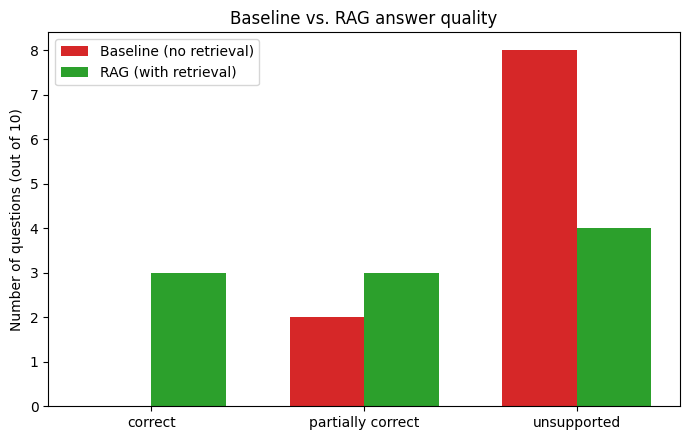

In [12]:
import matplotlib.pyplot as plt

RESULTS_DIR = Path("..") / "results"
RESULTS_DIR.mkdir(exist_ok=True)

verdict_order = ["correct", "partially correct", "unsupported"]
baseline_counts = [sum(1 for r in eval_results if r["baseline_verdict"] == v) for v in verdict_order]
rag_counts = [sum(1 for r in eval_results if r["rag_verdict"] == v) for v in verdict_order]

x = list(range(len(verdict_order)))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar([i - width / 2 for i in x], baseline_counts, width, label="Baseline (no retrieval)", color="tab:red")
ax.bar([i + width / 2 for i in x], rag_counts, width, label="RAG (with retrieval)", color="tab:green")
ax.set_xticks(x)
ax.set_xticklabels(verdict_order)
ax.set_ylabel(f"Number of questions (out of {len(eval_results)})")
ax.set_title("Baseline vs. RAG answer quality")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "rag_before_after.png", dpi=150)
plt.show()

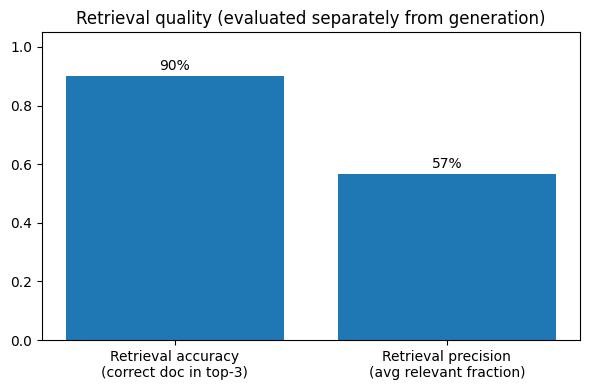

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = ["Retrieval accuracy\n(correct doc in top-3)", "Retrieval precision\n(avg relevant fraction)"]
values = [retrieval_accuracy, avg_retrieval_precision]
ax.bar(labels, values, color="tab:blue")
ax.set_ylim(0, 1.05)
for i, v in enumerate(values):
    ax.text(i, v + 0.02, f"{v:.0%}", ha="center")
ax.set_title("Retrieval quality (evaluated separately from generation)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "rag_retrieval_quality.png", dpi=150)
plt.show()

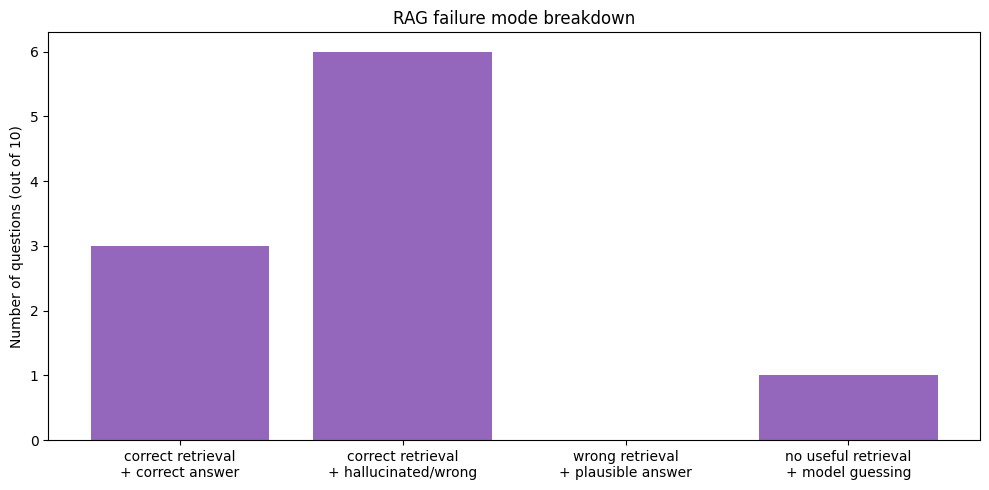

Saved: rag_before_after.png, rag_retrieval_quality.png, rag_failure_modes.png


In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
modes = ["correct retrieval\n+ correct answer", "correct retrieval\n+ hallucinated/wrong",
         "wrong retrieval\n+ plausible answer", "no useful retrieval\n+ model guessing"]
mode_keys = ["correct retrieval + correct answer", "correct retrieval + hallucinated/wrong answer",
             "wrong retrieval + plausible answer", "no useful retrieval + model guessing"]
counts = [mode_counts.get(k, 0) for k in mode_keys]
ax.bar(modes, counts, color="tab:purple")
ax.set_ylabel(f"Number of questions (out of {len(eval_results)})")
ax.set_title("RAG failure mode breakdown")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "rag_failure_modes.png", dpi=150)
plt.show()

print("Saved: rag_before_after.png, rag_retrieval_quality.png, rag_failure_modes.png")

## Final learning summary

**RAG changes what information the model can access at inference time without changing the model's weights. It can improve grounding, but it introduces a new retrieval layer that must itself be evaluated, versioned, secured, and observed.**

That last part is the easy thing to forget: RAG doesn't remove the need for evaluation, it adds a second surface to evaluate. Section 9's retrieval accuracy and Section 7's answer-grounding scores are two different numbers that can each fail independently -- exactly like notebook 04 showed that model quality isn't one number, this notebook shows that a RAG system's quality isn't one number either. Retrieval and generation each need their own metric, their own failure-mode analysis, and eventually their own regression suite, or a real improvement in one can silently mask a real regression in the other.